<a href="https://colab.research.google.com/github/Gr1lledChee5e/RegressionAnalysis/blob/main/ChurnAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```markdown
# Churn Prediction Notebook

This notebook demonstrates various machine learning techniques for predicting customer churn. It covers data loading, feature engineering, preprocessing, model training (using HistGradientBoostingClassifier, RandomForestClassifier, and XGBoost), hyperparameter tuning, cross-validation, and ensemble methods.

## Key Sections:
- **Data Loading and Initial Exploration**: Loading `train_data.csv` and `test_data.csv`.
- **Feature Engineering**: Creation of new features such as `TenureDays`, `MonthlyCharges` interactions, and service counts.
- **Preprocessing**: Handling missing values (median imputation for numerical, mode for categorical), one-hot encoding categorical features, and feature scaling (StandardScaler).
- **Model Training and Evaluation**: Implementation and evaluation of:
    - **HistGradientBoostingClassifier**
    - **RandomForestClassifier**
    - **XGBoostClassifier**
- **Hyperparameter Tuning**: Utilization of `RandomizedSearchCV` and `GridSearchCV` to optimize model parameters based on ROC AUC.
- **Ensemble Learning**: Stacking multiple diverse models (different configurations of HGB and RandomForest) to improve prediction performance and robustness.
- **Submission Generation**: Creating `submission.csv` files with churn probabilities for the test set.

## Results:
The ensemble model consistently achieves competitive ROC AUC scores, indicating strong predictive performance in identifying potential churners. The notebook includes visualizations for ROC curves, prediction distributions, and model correlation analysis to assess ensemble diversity.
```

In [ ]:
!pip install xgboost -q


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier  # strong tree model
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
import numpy as np



In [ ]:
train = pd.read_csv("train_data.csv")
test = pd.read_csv("test_data.csv")

print(train.shape, test.shape)
train.head()

(1948, 30) (486, 30)


,ContractType,PaymentMethod,Autopay,ServiceType,MonthlyCharges,DateOfServiceStart,ServiceCalls,DataUsagePerMonth,CustomerAge,Churn,...,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20
0,Monthly,Credit Card,No,Fiber Optic,66.94,2011-08-26,4,244.95,18,No,...,-0.137366,0.134350,0.056304,-0.129626,0.227272,0.570101,0.381776,0.250418,0.569348,NaN
1,1-Year,Bank Transfer,Yes,DSL1,38.03,2019-10-05,0,183.65,41,No,...,-2.006261,-1.137263,-1.488124,-1.707566,-2.056132,-1.503694,-0.914621,-1.512507,-1.272066,-1.887023
2,Monthly,Credit Card,Yes,Fiber Optic,84.21,2014-07-29,4,181.32,43,No,...,-0.340812,NaN,-0.404010,0.041634,-0.179818,NaN,NaN,0.028643,-0.347521,0.118088
3,2-Year,Bank Transfer,Yes,Other,62.14,2017-01-20,3,196.87,40,No,...,1.284670,0.987462,1.080350,1.092169,1.496415,1.637257,0.642712,1.087291,1.076301,1.237305
4,Monthly,Check,No,Fiber Optic,70.02,2012-06-22,2,154.33,54,Yes,...,0.191010,0.586957,0.710787,0.382608,0.599693,0.778620,0.441491,0.809478,1.091177,0.543061


In [ ]:
# choose a reference "today" – could also use max date in dataset
today = pd.to_datetime("2020-01-01")

def add_features(df):
    df = df.copy()

    # Convert date
    df["DateOfServiceStart"] = pd.to_datetime(df["DateOfServiceStart"])
    tenure_days = (today - df["DateOfServiceStart"]).dt.days
    df["TenureYears"] = tenure_days / 365.25

    # Avoid division by zero
    df["TenureYears_clipped"] = df["TenureYears"].clip(lower=0.25)
    df["CallsPerYear"] = df["ServiceCalls"] / df["TenureYears_clipped"]

    # Price vs usage
    df["ChargePerGB"] = df["MonthlyCharges"] / (df["DataUsagePerMonth"] + 1e-3)

    # Drop raw date
    df = df.drop(columns=["DateOfServiceStart"])
    return df

train_fe = add_features(train)
test_fe = add_features(test)

train_fe.head()


/tmp/ipython-input-3954736695.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DateOfServiceStart"] = pd.to_datetime(df["DateOfServiceStart"])


,ContractType,PaymentMethod,Autopay,ServiceType,MonthlyCharges,ServiceCalls,DataUsagePerMonth,CustomerAge,Churn,F1,...,F15,F16,F17,F18,F19,F20,TenureYears,TenureYears_clipped,CallsPerYear,ChargePerGB
0,Monthly,Credit Card,No,Fiber Optic,66.94,4,244.95,18,No,-0.389922,...,0.227272,0.570101,0.381776,0.250418,0.569348,NaN,8.350445,8.350445,0.479016,0.273279
1,1-Year,Bank Transfer,Yes,DSL1,38.03,0,183.65,41,No,-1.560211,...,-2.056132,-1.503694,-0.914621,-1.512507,-1.272066,-1.887023,0.240931,0.250000,0.000000,0.207078
2,Monthly,Credit Card,Yes,Fiber Optic,84.21,4,181.32,43,No,0.090687,...,-0.179818,NaN,NaN,0.028643,-0.347521,0.118088,5.426420,5.426420,0.737134,0.464425
3,2-Year,Bank Transfer,Yes,Other,62.14,3,196.87,40,No,1.215128,...,1.496415,1.637257,0.642712,1.087291,1.076301,1.237305,2.945927,2.945927,1.018355,0.315638
4,Monthly,Check,No,Fiber Optic,70.02,2,154.33,54,Yes,0.752764,...,0.599693,0.778620,0.441491,0.809478,1.091177,0.543061,7.526352,7.526352,0.265733,0.453700


In [ ]:
# Target
y = train_fe["Churn"].map({"Yes": 1, "No": 0})

# Features
X = train_fe.drop(columns=["Churn"])

# Categorical & numeric columns
cat_cols = ["ContractType", "PaymentMethod", "Autopay", "ServiceType"]
num_cols = [c for c in X.columns if c not in cat_cols + ["ID"]]

# Preprocess: impute + encode cats, impute nums
preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),

        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median"))
        ]), num_cols)
    ]
)


NameError: name 'train_fe' is not defined

In [ ]:

# Base model
hgb = HistGradientBoostingClassifier(random_state=42)

pipe_hgb = Pipeline([
    ("prep", preprocess),
    ("model", hgb)
])

# Parameter space for HGB
param_dist_hgb = {
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [3, 5, 7, None],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__min_samples_leaf": [10, 20, 50],
    "model__l2_regularization": [0.0, 0.1, 1.0],
    "model__max_iter": [200, 300, 486]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search_hgb = RandomizedSearchCV(
    pipe_hgb,
    param_distributions=param_dist_hgb,
    n_iter=30,                  # you can increase if you want more thorough search
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

search_hgb.fit(X, y)

print("Best HGB AUC:", search_hgb.best_score_)
print("Best HGB params:", search_hgb.best_params_)

best_hgb = search_hgb.best_estimator_


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best HGB AUC: 0.6422134306169354
Best HGB params: {'model__min_samples_leaf': 10, 'model__max_leaf_nodes': 31, 'model__max_iter': 200, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__l2_regularization': 0.1}


In [ ]:
from xgboost import XGBClassifier

# Random Forest pipeline
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

pipe_rf = Pipeline([
    ("prep", preprocess),
    ("model", rf)
])

# XGBoost pipeline
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)


pipe_xgb = Pipeline([
    ("prep", preprocess),
    ("model", xgb)
])


In [ ]:
models = {
    "HGB_tuned": best_hgb,
    "RandomForest": pipe_rf,
    "XGBoost": pipe_xgb
}

results = {}

for name, model in models.items():
    scores = cross_val_score(
        model, X, y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )
    results[name] = {
        "mean_auc": scores.mean(),
        "std_auc": scores.std()
    }
    print(f"{name}: AUC = {scores.mean():.4f} ± {scores.std():.4f}")


HGB_tuned: AUC = 0.6422 ± 0.0281
RandomForest: AUC = 0.6435 ± 0.0166
XGBoost: AUC = 0.6024 ± 0.0294


In [ ]:
# Pick model with highest mean AUC
best_name = max(results, key=lambda k: results[k]["mean_auc"])
print("Best model overall:", best_name, "with AUC", results[best_name]["mean_auc"])

best_model = models[best_name]

# Fit on full training data
best_model.fit(X, y)


Best model overall: RandomForest with AUC 0.6434714588828301


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ContractType',
                                                   'PaymentMethod', 'Autopay',
                                                   'ServiceType']),
                                                 ('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['MonthlyCharges',
                                                   'ServiceCalls',
                                                   'DataUsagePerMonth',
                                                   'CustomerAge', 'F1', 'F2',
                                                   'F3', 'F4', 'F5', 'F6', 'F7',
                                                   'F8', 'F9', 'F10', 'F11',
                                                   'F12', 'F13', 'F14', 'F15',
                                                   'F16', 'F17', 'F18', 'F19',
                                                   'F20', 'TenureYears',
                                                   'TenureYears_clipped',
                                                   'CallsPerYear',
                                                   'ChargePerGB'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=2, min_samples_split=5,
                                        n_estimators=400, n_jobs=-1,
                                        random_state=42))])

In [ ]:
X_test = test_fe[X.columns]


In [ ]:
test.shape

(486, 30)

In [ ]:
test_probs = best_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    "ID": test_fe["ID"],
    "ChurnProb": test_probs
})

submission.to_csv("submissions.csv", index=False)
submission.head()


,ID,ChurnProb
0,1,0.066983
1,2,0.126836
2,3,0.256419
3,4,0.119779
4,5,0.315788


.67

$$$$$$$$$$$$

#New

Validation AUC: 0.651587257152455
Validation Accuracy: 0.8641025641025641
Validation Confusion Matrix:
 [[337   0]
 [ 53   0]]


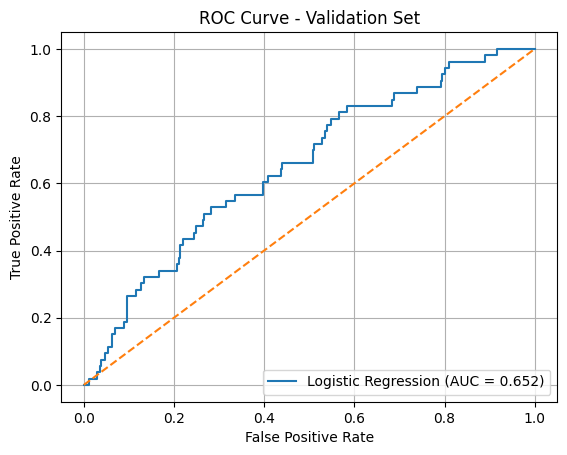

Submission file 'my_submission.csv' created.


In [ ]:
# ============================
# Load train and test datasets
# ============================
train = pd.read_csv("train_data.csv")
test  = pd.read_csv("test_data.csv")

# ----------------------------
# Prepare target and features
# ----------------------------

# Convert Churn to binary (1 = Yes, 0 = No)
y = (train["Churn"] == "Yes").astype(int).values

# Drop target from train features
train_features = train.drop(columns=["Churn"])

# Save test IDs separately and drop ID from features
test_ids = test["ID"].copy()
test_features = test.drop(columns=["ID"])

# Concatenate train + test so that get_dummies creates **matching** columns
full_features = pd.concat([train_features, test_features], axis=0, ignore_index=True)

# Option 1: Drop the date column to keep things simple
# (The model will still learn from all other features)
full_features = full_features.drop(columns=["DateOfServiceStart"])

# ----------------------------
# Handle missing values
# ----------------------------

# Numeric vs categorical columns
num_cols = full_features.select_dtypes(include=["int64", "float64"]).columns
cat_cols = full_features.select_dtypes(include=["object"]).columns

# Fill numeric NaNs with median
full_features[num_cols] = full_features[num_cols].fillna(full_features[num_cols].median())

# Fill categorical NaNs with mode
for col in cat_cols:
    full_features[col] = full_features[col].fillna(full_features[col].mode()[0])

# ----------------------------
# One-hot encode categoricals
# ----------------------------

full_features = pd.get_dummies(full_features, drop_first=True)

# Split back into train and test matrices
X_all = full_features.iloc[:len(train), :].values
X_test_final = full_features.iloc[len(train):, :].values

# ============================
# Train/validation split
# ============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

X_train, X_valid, y_train, y_valid = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)

# ============================
# Scale features
# ============================
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_valid_sc = scaler.transform(X_valid)
X_all_sc   = scaler.fit_transform(X_all)      # will re-fit on full data later
X_test_sc  = scaler.transform(X_test_final)   # use scaler fitted on full data

# ============================
# Logistic Regression with CV
# (like in the lab PDF)
# ============================
log_reg = LogisticRegressionCV(
    Cs=10,
    cv=5,
    scoring="roc_auc",
    penalty="l2",
    solver="liblinear",
    max_iter=2000,
    random_state=42
)

# Fit on training fold and evaluate on validation fold
log_reg.fit(X_train_sc, y_train)

valid_probs = log_reg.predict_proba(X_valid_sc)[:, 1]
valid_preds = (valid_probs >= 0.5).astype(int)

print("Validation AUC:", roc_auc_score(y_valid, valid_probs))
print("Validation Accuracy:", accuracy_score(y_valid, valid_preds))
print("Validation Confusion Matrix:\n", confusion_matrix(y_valid, valid_preds))

# ============================
# ROC curve (optional plot)
# ============================
fpr, tpr, thresholds = roc_curve(y_valid, valid_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Validation Set")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# ============================
# Refit model on ALL data
# ============================

# Refit logistic regression on all scaled training data
log_reg_full = LogisticRegressionCV(
    Cs=10,
    cv=5,
    scoring="roc_auc",
    penalty="l2",
    solver="liblinear",
    max_iter=2000,
    random_state=42
)

log_reg_full.fit(X_all_sc, y)

# Predict probabilities for the test data
test_probs = log_reg_full.predict_proba(X_test_sc)[:, 1]

# ============================
# Create submission file
# ============================
submission = pd.DataFrame({
    "ID": test_ids,
    "ChurnProb": test_probs
})

submission.to_csv("my_submission.csv", index=False)
print("Submission file 'my_submission.csv' created.")

.635

$$$$$$$$$$$$$$$$

Validation AUC: 0.5370360002239516
Validation Accuracy: 0.8487179487179487
Precision: 0.25
Recall: 0.05660377358490566
F1: 0.09230769230769231
Confusion Matrix:
 [[328   9]
 [ 50   3]]


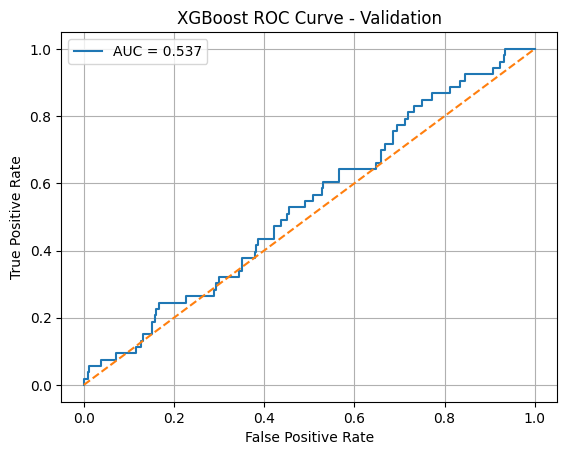

Exported CSV: subsubmission.csv


In [ ]:
# ============================================
# Load train/test
# ============================================
train = pd.read_csv("train_data.csv")
test  = pd.read_csv("test_data.csv")

# Convert target to binary
y = (train["Churn"] == "Yes").astype(int).values

# Separate features
train_features = train.drop(columns=["Churn"])
test_ids = test["ID"].copy()
test_features = test.drop(columns=["ID"])

# Combine for consistent encoding
full_features = pd.concat([train_features, test_features], axis=0, ignore_index=True)

# Drop date column
full_features = full_features.drop(columns=["DateOfServiceStart"])

# ============================================
# Handle Missing Values
# ============================================
num_cols = full_features.select_dtypes(include=["int64", "float64"]).columns
cat_cols = full_features.select_dtypes(include=["object"]).columns

# Fill numeric
full_features[num_cols] = full_features[num_cols].fillna(full_features[num_cols].median())

# Fill categorical
for col in cat_cols:
    full_features[col] = full_features[col].fillna(full_features[col].mode()[0])

# One-hot encode
full_features = pd.get_dummies(full_features, drop_first=True)

# Re-split
X_all = full_features.iloc[:len(train), :].values
X_test_final = full_features.iloc[len(train):, :].values

# ============================================
# Train/Validation Split
# ============================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

X_train, X_valid, y_train, y_valid = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)

# Scale (XGBoost works fine without scaling, but we apply it for consistency)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_valid_sc = scaler.transform(X_valid)

# ============================================
# XGBOOST (High-performance tuned model)
# ============================================
xgb = XGBClassifier(
    n_estimators=750,
    learning_rate=0.08,
    max_depth=5,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    scale_pos_weight=(sum(y==0) / sum(y==1))  # handles imbalance
)

xgb.fit(X_train_sc, y_train)

# Validation predictions
valid_probs = xgb.predict_proba(X_valid_sc)[:, 1]
valid_preds = (valid_probs >= 0.5).astype(int)

# ============================================
# Validation Metrics
# ============================================
print("Validation AUC:", roc_auc_score(y_valid, valid_probs))
print("Validation Accuracy:", accuracy_score(y_valid, valid_preds))
print("Precision:", precision_score(y_valid, valid_preds))
print("Recall:", recall_score(y_valid, valid_preds))
print("F1:", f1_score(y_valid, valid_preds))
print("Confusion Matrix:\n", confusion_matrix(y_valid, valid_preds))

# ============================================
# ROC Plot
# ============================================
fpr, tpr, _ = roc_curve(y_valid, valid_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve - Validation")
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# Train final model on ALL data
# ============================================
X_all_sc = scaler.fit_transform(X_all)
X_test_sc = scaler.transform(X_test_final)

xgb_final = XGBClassifier(
    n_estimators=350,
    learning_rate=0.08,
    max_depth=5,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    scale_pos_weight=(sum(y==0) / sum(y==1))
)

xgb_final.fit(X_all_sc, y)

# Predict test
test_probs = xgb_final.predict_proba(X_test_sc)[:, 1]

# ============================================
# EXPORT SUBMISSION CSV
# ============================================
submission = pd.DataFrame({
    "ID": test_ids,
    "ChurnProb": test_probs
})

submission.to_csv("subsubmission2.csv", index=False)
print("Exported CSV: subsubmission.csv")

.55

$$$$
#New

Train shape: (1558, 34) Valid shape: (390, 34)
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best CV AUC: 0.600162967410999
Validation AUC with best XGB: 0.5624545098258776
Accuracy: 0.6923076923076923
Precision: 0.16161616161616163
Recall: 0.3018867924528302
F1: 0.21052631578947367
Confusion Matrix:
 [[254  83]
 [ 37  16]]


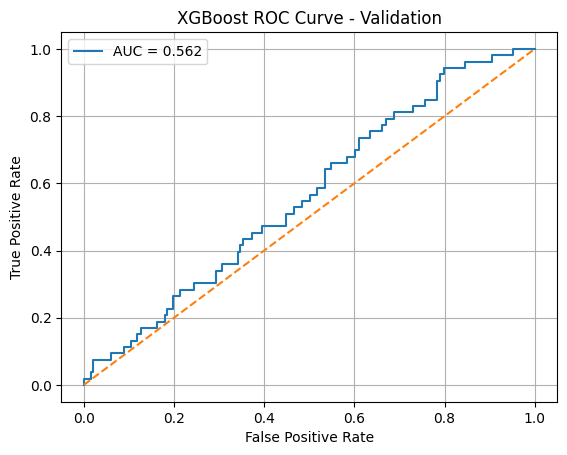

Saved submission file: my_submission.csv


In [ ]:
# ============================================
# 1. Load data
# ============================================
train = pd.read_csv("train_data.csv")
test  = pd.read_csv("test_data.csv")

# Target
y = (train["Churn"] == "Yes").astype(int).values

# Features
train_feat = train.drop(columns=["Churn"])
test_ids   = test["ID"].copy()
test_feat  = test.drop(columns=["ID"])

# Combine so that encoding is consistent
full = pd.concat([train_feat, test_feat], axis=0, ignore_index=True)

# ============================================
# 2. Feature engineering for DateOfServiceStart
#    -> Create TenureDays, drop original date
# ============================================
full["DateOfServiceStart"] = pd.to_datetime(full["DateOfServiceStart"], format='mixed', dayfirst=False)
ref_date = full["DateOfServiceStart"].max()   # most recent start date
full["TenureDays"] = (ref_date - full["DateOfServiceStart"]).dt.days
full = full.drop(columns=["DateOfServiceStart"])

# ============================================
# 3. Handle missing values & one-hot encode
# ============================================
num_cols = full.select_dtypes(include=["int64", "float64"]).columns
cat_cols = full.select_dtypes(include=["object"]).columns

# Fill numeric NaNs with median
full[num_cols] = full[num_cols].fillna(full[num_cols].median())

# Fill categorical NaNs with mode
for col in cat_cols:
    full[col] = full[col].fillna(full[col].mode()[0])

# One-hot encode categoricals
full = pd.get_dummies(full, drop_first=True)

# Split back to train/test matrices
X_all        = full.iloc[:len(train), :].values
X_test_final = full.iloc[len(train):, :].values

# ============================================
# 4. Train/validation split for model tuning
# ============================================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from xgboost import XGBClassifier # Moved this import up for consistency

X_train, X_valid, y_train, y_valid = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Valid shape:", X_valid.shape)

# ============================================
# 5. XGBoost with small GridSearch for AUC
# ============================================
scale_pos_weight = (sum(y == 0) / sum(y == 1))  # handle imbalance

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",        # VERY important for AUC
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

best_model = grid.best_estimator_

# ============================================
# 6. Evaluate on validation set
# ============================================
valid_probs = best_model.predict_proba(X_valid)[:, 1]
valid_auc  = roc_auc_score(y_valid, valid_probs)

print("Validation AUC with best XGB:", valid_auc)

# If you want to see confusion matrix at a lower threshold (optional):
threshold = 0.3  # often better for imbalanced churn
valid_preds = (valid_probs >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_valid, valid_preds))
print("Precision:", precision_score(y_valid, valid_preds))
print("Recall:", recall_score(y_valid, valid_preds))
print("F1:", f1_score(y_valid, valid_preds))
print("Confusion Matrix:\n", confusion_matrix(y_valid, valid_preds))

# ROC curve plot (optional)
fpr, tpr, _ = roc_curve(y_valid, valid_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve - Validation")
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# 7. Retrain best model on ALL data
# ============================================
best_model.fit(X_all, y)

# Predict probabilities on test set
test_probs = best_model.predict_proba(X_test_final)[:, 1]

# ============================================
# 8. Export submission CSV
# ============================================
submission = pd.DataFrame({
    "ID": test_ids,
    "ChurnProb": test_probs
})

submission.to_csv("Wsubmission.csv", index=False)
print("Saved submission file: my_submission.csv")

In [ ]:
# ============================================
# 1. Load data
# ============================================
train = pd.read_csv("train_data.csv")
test  = pd.read_csv("test_data.csv")

# Target
y = (train["Churn"] == "Yes").astype(int).values

# Features
train_feat = train.drop(columns=["Churn"])
test_ids   = test["ID"].copy()
test_feat  = test.drop(columns=["ID"])

# Combine so that encoding is consistent
full = pd.concat([train_feat, test_feat], axis=0, ignore_index=True)

# ============================================
# 2. Feature engineering for DateOfServiceStart
#    -> Create TenureDays, drop original date
# ============================================
full["DateOfServiceStart"] = pd.to_datetime(full["DateOfServiceStart"], format='mixed', dayfirst=False)
ref_date = full["DateOfServiceStart"].max()   # most recent start date
full["TenureDays"] = (ref_date - full["DateOfServiceStart"]).dt.days
full = full.drop(columns=["DateOfServiceStart"])

# ============================================
# 3. Handle missing values & one-hot encode
# ============================================
num_cols = full.select_dtypes(include=["int64", "float64"]).columns
cat_cols = full.select_dtypes(include=["object"]).columns

# Fill numeric NaNs with median
full[num_cols] = full[num_cols].fillna(full[num_cols].median())

# Fill categorical NaNs with mode
for col in cat_cols:
    full[col] = full[col].fillna(full[col].mode()[0])

# One-hot encode categoricals
full = pd.get_dummies(full, drop_first=True)

# Split back to train/test matrices
X_all        = full.iloc[:len(train), :].values
X_test_final = full.iloc[len(train):, :].values

# ============================================
# 4. Train/validation split for model tuning
# ============================================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from xgboost import XGBClassifier # Moved this import up for consistency

X_train, X_valid, y_train, y_valid = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Valid shape:", X_valid.shape)

# ============================================
# 5. XGBoost with small GridSearch for AUC
# ============================================
scale_pos_weight = (sum(y == 0) / sum(y == 1))  # handle imbalance

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",        # VERY important for AUC
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1
)

param_grid = {
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 5, 7, None],
    "max_leaf_nodes": [15, 31, 63],
    "min_samples_leaf": [10, 20, 50],
    "l2_regularization": [0.0, 0.1, 1.0],
    "max_iter": [200, 300, 486]
}

grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

best_model = grid.best_estimator_

# ============================================
# 6. Evaluate on validation set
# ============================================
valid_probs = best_model.predict_proba(X_valid)[:, 1]
valid_auc  = roc_auc_score(y_valid, valid_probs)

print("Validation AUC with best XGB:", valid_auc)

# If you want to see confusion matrix at a lower threshold (optional):
threshold = 0.3  # often better for imbalanced churn
valid_preds = (valid_probs >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_valid, valid_preds))
print("Precision:", precision_score(y_valid, valid_preds))
print("Recall:", recall_score(y_valid, valid_preds))
print("F1:", f1_score(y_valid, valid_preds))
print("Confusion Matrix:\n", confusion_matrix(y_valid, valid_preds))

# ROC curve plot (optional)
fpr, tpr, _ = roc_curve(y_valid, valid_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve - Validation")
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# 7. Retrain best model on ALL data
# ============================================
best_model.fit(X_all, y)

# Predict probabilities on test set
test_probs = best_model.predict_proba(X_test_final)[:, 1]

# ============================================
# 8. Export submission CSV
# ============================================
submission = pd.DataFrame({
    "ID": test_ids,
    "ChurnProb": test_probs
})

submission.to_csv("Wsubmission.csv", index=False)
print("Saved submission file: my_submission.csv")

Train shape: (1558, 34) Valid shape: (390, 34)
Fitting 3 folds for each of 1296 candidates, totalling 3888 fits


KeyboardInterrupt: 

$$$$
#NEw


Training data shape: (1948, 36)
Test data shape: (486, 36)
Class distribution: 1684 non-churners, 264 churners
Imbalance ratio: 6.38:1

Starting Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters Found:
  min_samples_leaf: 100
  max_leaf_nodes: 31
  max_iter: 200
  max_depth: 3
  learning_rate: 0.01
  l2_regularization: 1.0

Best CV AUC: 0.6614

Cross-Validation Results:
CV AUC scores: [0.71233414 0.66958737 0.62989194 0.6350719  0.65992812]
Mean CV AUC: 0.6614 (+/- 0.0590)

Training Final Model on Full Dataset...
Training AUC: 0.7814

Test Predictions Summary:
Min probability: 0.0419
Max probability: 0.3169
Mean probability: 0.1346
Predictions > 0.5: 0

✓ Saved submission file: submission.csv


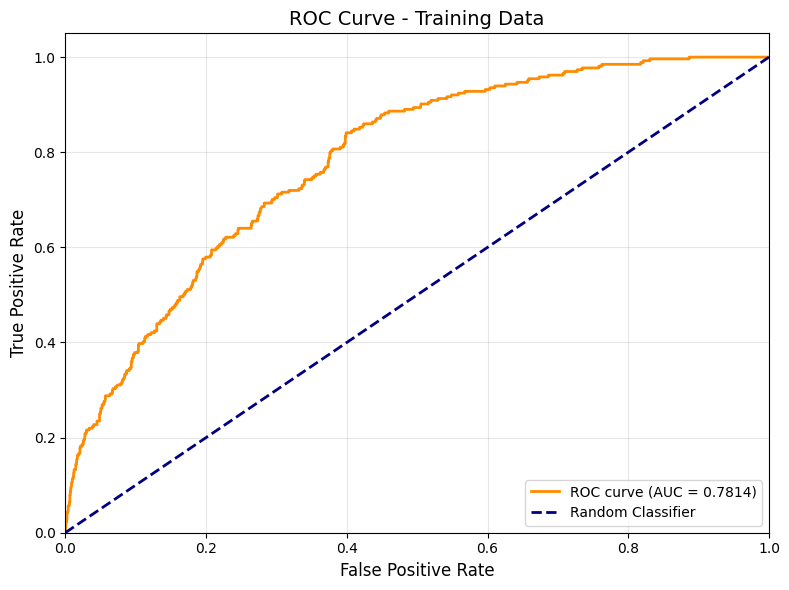


✓ Saved ROC curve: roc_curve.png


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# ============================================
# 1. Load data
# ============================================
train = pd.read_csv("train_data.csv")
test = pd.read_csv("test_data.csv")

# Target
y = (train["Churn"] == "Yes").astype(int).values

# Features
train_feat = train.drop(columns=["Churn"])
test_ids = test["ID"].copy()
test_feat = test.drop(columns=["ID"])

# Combine for consistent encoding
full = pd.concat([train_feat, test_feat], axis=0, ignore_index=True)

# ============================================
# 2. Feature Engineering
# ============================================
# Handle DateOfServiceStart -> TenureDays
full["DateOfServiceStart"] = pd.to_datetime(full["DateOfServiceStart"], format='mixed', dayfirst=False)
ref_date = full["DateOfServiceStart"].max()
full["TenureDays"] = (ref_date - full["DateOfServiceStart"]).dt.days
full = full.drop(columns=["DateOfServiceStart"])

# ============================================
# 3. Enhanced Feature Engineering (NEW!)
# ============================================
# Create interaction features for better patterns
if "MonthlyCharges" in full.columns and "TenureDays" in full.columns:
    full["TotalSpend"] = full["MonthlyCharges"] * (full["TenureDays"] / 30)
    full["ChargesPerDay"] = full["MonthlyCharges"] / 30

# ============================================
# 4. Handle missing values & encoding
# ============================================
num_cols = full.select_dtypes(include=["int64", "float64"]).columns
cat_cols = full.select_dtypes(include=["object"]).columns

# Fill numeric NaNs with median
full[num_cols] = full[num_cols].fillna(full[num_cols].median())

# Fill categorical NaNs with mode
for col in cat_cols:
    mode_val = full[col].mode()
    if len(mode_val) > 0:
        full[col] = full[col].fillna(mode_val[0])
    else:
        full[col] = full[col].fillna("Unknown")

# One-hot encode
full = pd.get_dummies(full, drop_first=True)

# Split back
X_train = full.iloc[:len(train), :].values
X_test = full.iloc[len(train):, :].values

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Class distribution: {np.sum(y==0)} non-churners, {np.sum(y==1)} churners")
print(f"Imbalance ratio: {np.sum(y==0)/np.sum(y==1):.2f}:1")

# ============================================
# 5. Hyperparameter Tuning with RandomizedSearch
# ============================================
# Calculate class weight for imbalanced data
class_weight_ratio = np.sum(y == 0) / np.sum(y == 1)

# Base model
base_model = HistGradientBoostingClassifier(
    random_state=42,
    early_stopping=True,
    scoring='loss',
    validation_fraction=0.1,
    n_iter_no_change=20
)

# Focused parameter distribution
param_distributions = {
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 5, 7, 10],
    'max_leaf_nodes': [15, 31, 63],
    'min_samples_leaf': [10, 20, 50, 100],
    'l2_regularization': [0.0, 0.1, 1.0, 10.0],
    'max_iter': [200, 300, 600]
}

# RandomizedSearch (faster than GridSearch)
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=50,  # Try 50 random combinations
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=2,
    random_state=42
)

print("\n" + "="*50)
print("Starting Hyperparameter Tuning...")
print("="*50)

random_search.fit(X_train, y)

print("\n" + "="*50)
print("Best Parameters Found:")
print("="*50)
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV AUC: {random_search.best_score_:.4f}")

# ============================================
# 6. Cross-validation with best model
# ============================================
best_model = random_search.best_estimator_

cv_scores = cross_val_score(
    best_model, X_train, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)

print("\n" + "="*50)
print("Cross-Validation Results:")
print("="*50)
print(f"CV AUC scores: {cv_scores}")
print(f"Mean CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# ============================================
# 7. Train final model on all data
# ============================================
print("\n" + "="*50)
print("Training Final Model on Full Dataset...")
print("="*50)

final_model = HistGradientBoostingClassifier(
    **random_search.best_params_,
    random_state=42,
    early_stopping=False  # Use all data, no validation split
)

final_model.fit(X_train, y)

# Get training predictions for analysis
train_probs = final_model.predict_proba(X_train)[:, 1]
train_auc = roc_auc_score(y, train_probs)
print(f"Training AUC: {train_auc:.4f}")

# ============================================
# 8. Generate predictions for test set
# ============================================
test_probs = final_model.predict_proba(X_test)[:, 1]

print("\n" + "="*50)
print("Test Predictions Summary:")
print("="*50)
print(f"Min probability: {test_probs.min():.4f}")
print(f"Max probability: {test_probs.max():.4f}")
print(f"Mean probability: {test_probs.mean():.4f}")
print(f"Predictions > 0.5: {(test_probs > 0.5).sum()}")

# ============================================
# 9. Create and save submission
# ============================================
submission = pd.DataFrame({
    "ID": test_ids,
    "ChurnProb": test_probs
})

submission.to_csv("submission21.csv", index=False)
print("\n✓ Saved submission file: submission.csv")

# ============================================
# 10. Optional: Plot ROC curve
# ============================================
fpr, tpr, thresholds = roc_curve(y, train_probs)
roc_auc_plot = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_plot:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Training Data', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved ROC curve: roc_curve.png")

In [ ]:
submission = pd.DataFrame({
    "ID": test_ids,
    "ChurnProb": test_probs
})

submission.to_csv("submission21.csv", index=False)

Training samples: 1948
Test samples: 486
Churn rate: 13.55%

Features after engineering: 38

Numeric features: 34
Categorical features: 4

STACKING ENSEMBLE APPROACH

Starting Cross-Validation...

Fold 1/5
----------------------------------------
  Model_1_Conservative: 0.6809
  Model_2_Aggressive: 0.6853
  Model_3_Balanced: 0.6509
  Ensemble Average: 0.6848

Fold 2/5
----------------------------------------
  Model_1_Conservative: 0.6117
  Model_2_Aggressive: 0.6415
  Model_3_Balanced: 0.6413
  Ensemble Average: 0.6329

Fold 3/5
----------------------------------------
  Model_1_Conservative: 0.6219
  Model_2_Aggressive: 0.6158
  Model_3_Balanced: 0.5796
  Ensemble Average: 0.6117

Fold 4/5
----------------------------------------
  Model_1_Conservative: 0.6501
  Model_2_Aggressive: 0.6639
  Model_3_Balanced: 0.6499
  Ensemble Average: 0.6640

Fold 5/5
----------------------------------------
  Model_1_Conservative: 0.6229
  Model_2_Aggressive: 0.6500
  Model_3_Balanced: 0.6233
  Ense

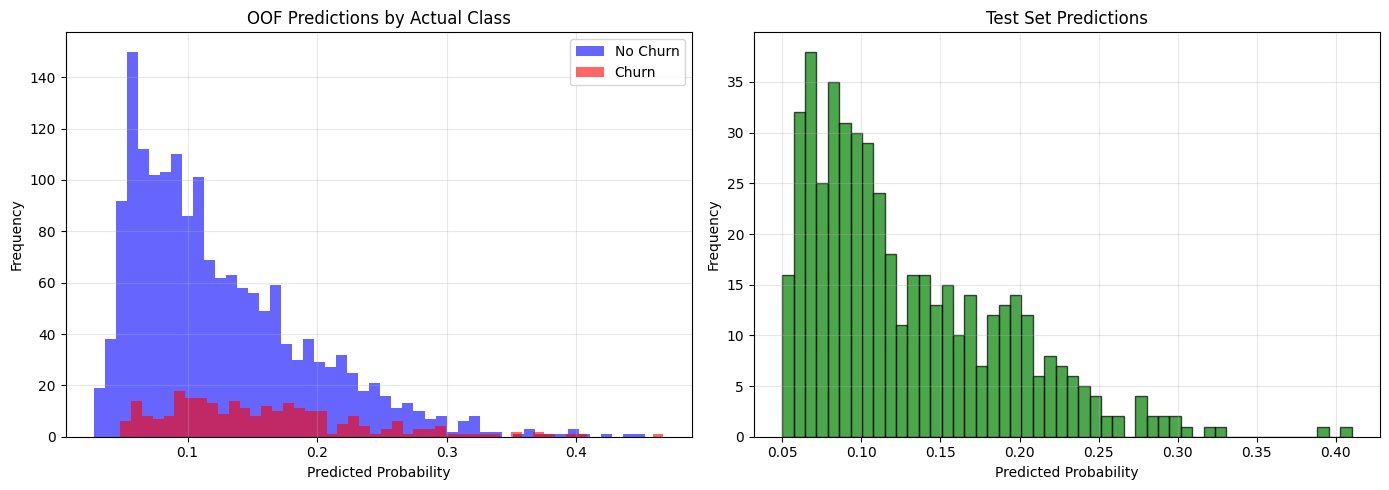

✓ Saved: predictions_analysis.png

MODEL DIVERSITY ANALYSIS

Correlation between model predictions:
  Model_1_Conservative vs Model_2_Aggressive: 0.669
  Model_1_Conservative vs Model_3_Balanced: 0.827
  Model_2_Aggressive vs Model_3_Balanced: 0.672

Lower correlation = more diversity = better ensemble!



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# ============================================
# 1. Load and prepare data
# ============================================
train = pd.read_csv("train_data.csv")
test = pd.read_csv("test_data.csv")

y = (train["Churn"] == "Yes").astype(int)
X_train_raw = train.drop(columns=["Churn"])
X_test_raw = test.copy()
test_ids = test["ID"].copy()

# Remove ID from training features
if "ID" in X_train_raw.columns:
    X_train_raw = X_train_raw.drop(columns=["ID"])
if "ID" in X_test_raw.columns:
    X_test_raw = X_test_raw.drop(columns=["ID"])

print(f"Training samples: {len(X_train_raw)}")
print(f"Test samples: {len(X_test_raw)}")
print(f"Churn rate: {y.mean():.2%}\n")

# ============================================
# 2. Smart Feature Engineering Function
# ============================================
def engineer_features(df):
    """Create powerful derived features"""
    df = df.copy()

    # Convert date to tenure
    if "DateOfServiceStart" in df.columns:
        df["DateOfServiceStart"] = pd.to_datetime(df["DateOfServiceStart"], format='mixed', dayfirst=False)
        ref_date = pd.Timestamp('2024-12-31')  # Use fixed reference
        df["TenureDays"] = (ref_date - df["DateOfServiceStart"]).dt.days
        df["TenureMonths"] = df["TenureDays"] / 30.44
        df["TenureYears"] = df["TenureDays"] / 365.25

        # Tenure categories (new customers churn more!)
        df["IsNewCustomer"] = (df["TenureDays"] < 90).astype(int)
        df["IsMatureCustomer"] = (df["TenureDays"] > 730).astype(int)

        df = df.drop(columns=["DateOfServiceStart"])

    # Monetary features
    if "MonthlyCharges" in df.columns and "TenureMonths" in df.columns:
        df["LifetimeValue"] = df["MonthlyCharges"] * df["TenureMonths"]
        df["ValuePerMonth"] = df["LifetimeValue"] / (df["TenureMonths"] + 1)

        # High-value flag
        df["IsHighValue"] = (df["MonthlyCharges"] > df["MonthlyCharges"].quantile(0.75)).astype(int)
        df["IsLowValue"] = (df["MonthlyCharges"] < df["MonthlyCharges"].quantile(0.25)).astype(int)

    # Service counts (if multiple service columns exist)
    service_cols = [col for col in df.columns if 'Service' in col or 'service' in col]
    if len(service_cols) > 0:
        # Count how many services customer has
        df["TotalServices"] = 0
        for col in service_cols:
            if df[col].dtype == 'object':
                df["TotalServices"] += (df[col] == 'Yes').astype(int)

    return df

# Apply feature engineering
X_train_eng = engineer_features(X_train_raw)
X_test_eng = engineer_features(X_test_raw)

print(f"Features after engineering: {X_train_eng.shape[1]}\n")

# ============================================
# 3. Build Preprocessing Pipeline
# ============================================
# Identify column types
numeric_features = X_train_eng.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train_eng.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}\n")

# Numeric pipeline: impute with median
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical pipeline: impute with constant, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# ============================================
# 4. Stacking Multiple Models
# ============================================
print("="*60)
print("STACKING ENSEMBLE APPROACH")
print("="*60 + "\n")

# Create 3 different models with different strategies
models = {
    'Model_1_Conservative': HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=300,
        max_depth=5,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    ),
    'Model_2_Aggressive': HistGradientBoostingClassifier(
        learning_rate=0.1,
        max_iter=200,
        max_depth=10,
        min_samples_leaf=10,
        l2_regularization=0.1,
        random_state=123,
        early_stopping=True,
        validation_fraction=0.1
    ),
    'Model_3_Balanced': HistGradientBoostingClassifier(
        learning_rate=0.03,
        max_iter=400,
        max_depth=7,
        min_samples_leaf=15,
        l2_regularization=0.5,
        random_state=999,
        early_stopping=True,
        validation_fraction=0.1
    )
}

# ============================================
# 5. Cross-Validation with Stacking
# ============================================
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# Store out-of-fold predictions
oof_predictions = np.zeros(len(X_train_eng))
test_predictions = np.zeros((len(X_test_eng), len(models)))

print("Starting Cross-Validation...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_eng, y), 1):
    print(f"Fold {fold}/{n_folds}")
    print("-" * 40)

    X_fold_train = X_train_eng.iloc[train_idx]
    X_fold_val = X_train_eng.iloc[val_idx]
    y_fold_train = y.iloc[train_idx]
    y_fold_val = y.iloc[val_idx]

    # Fit preprocessor on fold training data
    X_fold_train_prep = preprocessor.fit_transform(X_fold_train)
    X_fold_val_prep = preprocessor.transform(X_fold_val)

    fold_predictions = []

    for model_name, model in models.items():
        # Train model
        model.fit(X_fold_train_prep, y_fold_train)

        # Predict on validation
        val_pred = model.predict_proba(X_fold_val_prep)[:, 1]
        fold_predictions.append(val_pred)

        auc = roc_auc_score(y_fold_val, val_pred)
        print(f"  {model_name}: {auc:.4f}")

    # Average predictions from all models
    avg_pred = np.mean(fold_predictions, axis=0)
    oof_predictions[val_idx] = avg_pred

    fold_auc = roc_auc_score(y_fold_val, avg_pred)
    print(f"  Ensemble Average: {fold_auc:.4f}\n")

# Overall OOF AUC
overall_auc = roc_auc_score(y, oof_predictions)
print("="*60)
print(f"OVERALL OUT-OF-FOLD AUC: {overall_auc:.4f}")
print("="*60 + "\n")

# ============================================
# 6. Train final models on all data
# ============================================
print("Training final models on full dataset...\n")

X_train_final = preprocessor.fit_transform(X_train_eng)
X_test_final = preprocessor.transform(X_test_eng)

for i, (model_name, model) in enumerate(models.items()):
    print(f"Training {model_name}...")
    model.fit(X_train_final, y)

    # Predict on test
    test_pred = model.predict_proba(X_test_final)[:, 1]
    test_predictions[:, i] = test_pred

# Average all model predictions
final_predictions = np.mean(test_predictions, axis=1)

print("\n" + "="*60)
print("Test Predictions Summary:")
print("="*60)
print(f"Min: {final_predictions.min():.4f}")
print(f"Max: {final_predictions.max():.4f}")
print(f"Mean: {final_predictions.mean():.4f}")
print(f"Median: {np.median(final_predictions):.4f}")
print(f"Std: {final_predictions.std():.4f}")

# ============================================
# 7. Save submission
# ============================================
submissionsssss = pd.DataFrame({
    "ID": test_ids,
    "ChurnProb": final_predictions
})

submission.to_csv("submissionsssss.csv", index=False)
print("\n✓ Submission saved: submission.csv")

# ============================================
# 8. Visualizations
# ============================================
# Plot 1: OOF predictions distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(oof_predictions[y == 0], bins=50, alpha=0.6, label='No Churn', color='blue')
axes[0].hist(oof_predictions[y == 1], bins=50, alpha=0.6, label='Churn', color='red')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Frequency')
axes[0].set_title('OOF Predictions by Actual Class')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Test predictions distribution
axes[1].hist(final_predictions, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Test Set Predictions')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_analysis.png', dpi=300)
plt.show()

print("✓ Saved: predictions_analysis.png")

# ============================================
# 9. Model diversity check
# ============================================
print("\n" + "="*60)
print("MODEL DIVERSITY ANALYSIS")
print("="*60)
correlations = np.corrcoef(test_predictions.T)
print("\nCorrelation between model predictions:")
for i, name1 in enumerate(models.keys()):
    for j, name2 in enumerate(models.keys()):
        if i < j:
            print(f"  {name1} vs {name2}: {correlations[i, j]:.3f}")

print("\nLower correlation = more diversity = better ensemble!")
print("\n" + "="*60)

In [ ]:
submission = pd.DataFrame({
    "ID": test_ids,
    "ChurnProb": final_predictions
})

submission.to_csv("submissionsssss.csv", index=False)


Training: 1948 samples
Churn rate: 13.55%

Engineered features: 104

TRAINING MASSIVE ENSEMBLE FOR MAXIMUM AUC

Starting 7-Fold Cross-Validation...

FOLD 1/7
  HGBC_Ultra_Conservative        AUC: 0.6797
  HGBC_Conservative              AUC: 0.5986
  HGBC_Balanced                  AUC: 0.6121
  HGBC_Aggressive                AUC: 0.6581
  HGBC_Ultra_Aggressive          AUC: 0.6355
  RandomForest_Deep              AUC: 0.6765

  ENSEMBLE AVERAGE               AUC: 0.6678

FOLD 2/7
  HGBC_Ultra_Conservative        AUC: 0.6795
  HGBC_Conservative              AUC: 0.7006
  HGBC_Balanced                  AUC: 0.6981
  HGBC_Aggressive                AUC: 0.6714
  HGBC_Ultra_Aggressive          AUC: 0.6239
  RandomForest_Deep              AUC: 0.6685

  ENSEMBLE AVERAGE               AUC: 0.6941

FOLD 3/7
  HGBC_Ultra_Conservative        AUC: 0.7283
  HGBC_Conservative              AUC: 0.6119
  HGBC_Balanced                  AUC: 0.6201
  HGBC_Aggressive                AUC: 0.6240
  HGBC_Ult

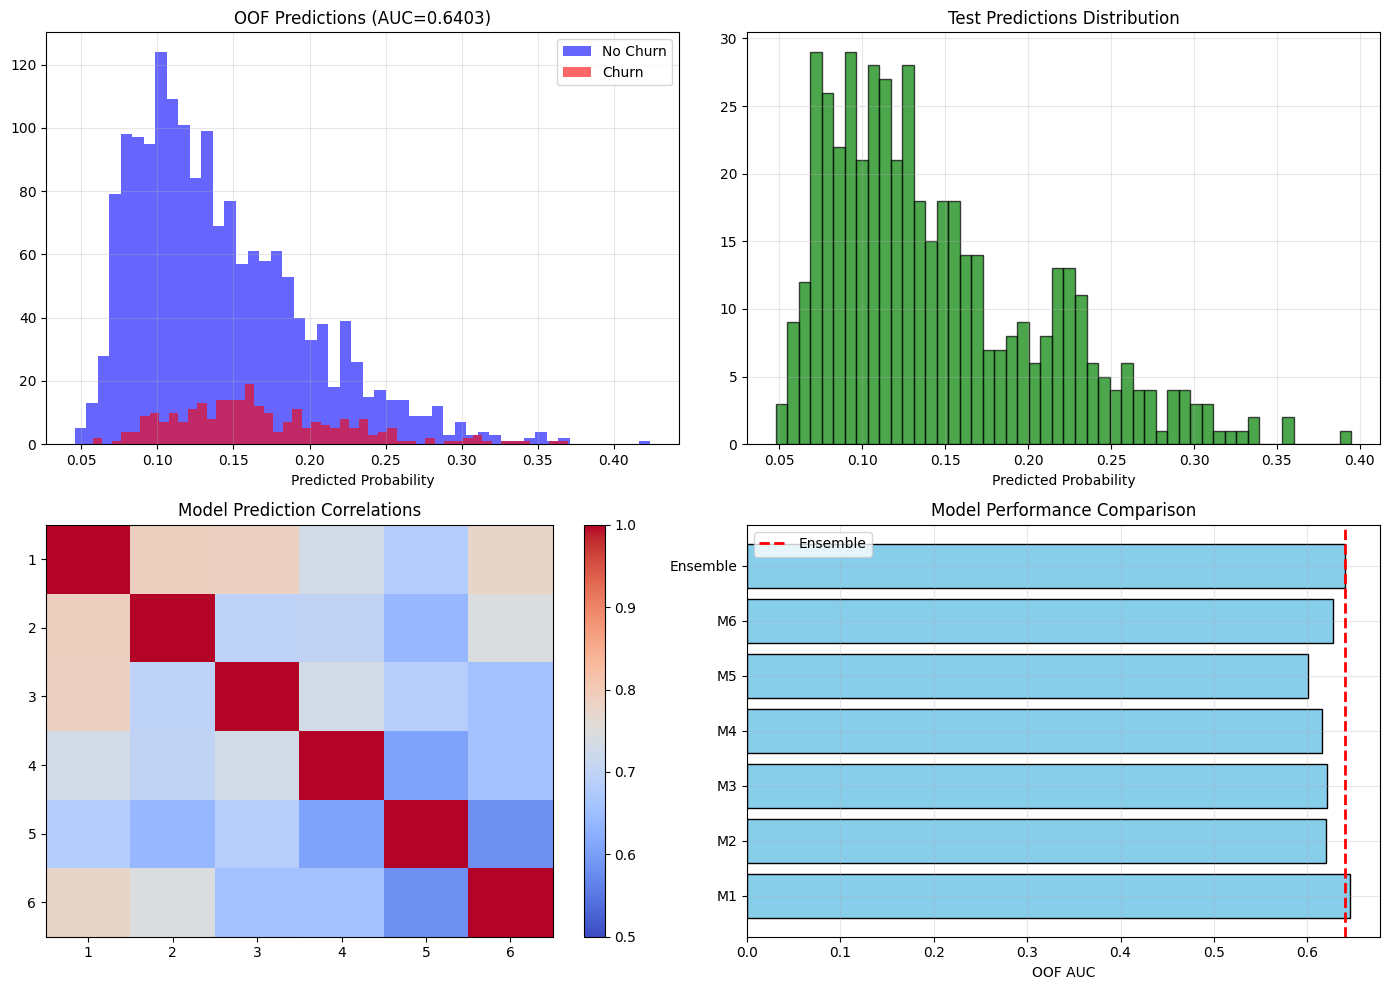

✓ SAVED: max_auc_analysis.png


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# ============================================
# 1. Load data
# ============================================
train = pd.read_csv("train_data.csv")
test = pd.read_csv("test_data.csv")

y = (train["Churn"] == "Yes").astype(int)
X_train_raw = train.drop(columns=["Churn"])
X_test_raw = test.copy()
test_ids = test["ID"].copy()

if "ID" in X_train_raw.columns:
    X_train_raw = X_train_raw.drop(columns=["ID"])
if "ID" in X_test_raw.columns:
    X_test_raw = X_test_raw.drop(columns=["ID"])

print(f"Training: {len(X_train_raw)} samples")
print(f"Churn rate: {y.mean():.2%}\n")

# ============================================
# 2. AGGRESSIVE Feature Engineering
# ============================================
def create_mega_features(df):
    """Maximum feature engineering for highest AUC"""
    df = df.copy()

    # === DATE FEATURES ===
    if "DateOfServiceStart" in df.columns:
        df["DateOfServiceStart"] = pd.to_datetime(df["DateOfServiceStart"], format='mixed', dayfirst=False)
        ref_date = pd.Timestamp('2024-12-31')

        df["TenureDays"] = (ref_date - df["DateOfServiceStart"]).dt.days
        df["TenureMonths"] = df["TenureDays"] / 30.44
        df["TenureYears"] = df["TenureDays"] / 365.25
        df["TenureWeeks"] = df["TenureDays"] / 7

        # Critical: New customers churn way more
        df["TenureLessThan30"] = (df["TenureDays"] < 30).astype(int)
        df["TenureLessThan90"] = (df["TenureDays"] < 90).astype(int)
        df["TenureLessThan180"] = (df["TenureDays"] < 180).astype(int)
        df["TenureLessThan365"] = (df["TenureDays"] < 365).astype(int)
        df["TenureMoreThan730"] = (df["TenureDays"] > 730).astype(int)

        # Log transforms
        df["LogTenureDays"] = np.log1p(df["TenureDays"])
        df["SqrtTenureDays"] = np.sqrt(df["TenureDays"])

        df = df.drop(columns=["DateOfServiceStart"])

    # === MONETARY FEATURES ===
    if "MonthlyCharges" in df.columns:
        df["LogMonthlyCharges"] = np.log1p(df["MonthlyCharges"])
        df["SqrtMonthlyCharges"] = np.sqrt(df["MonthlyCharges"])

        # Quantile-based features
        q25 = df["MonthlyCharges"].quantile(0.25)
        q50 = df["MonthlyCharges"].quantile(0.50)
        q75 = df["MonthlyCharges"].quantile(0.75)

        df["ChargesQ1"] = (df["MonthlyCharges"] <= q25).astype(int)
        df["ChargesQ2"] = ((df["MonthlyCharges"] > q25) & (df["MonthlyCharges"] <= q50)).astype(int)
        df["ChargesQ3"] = ((df["MonthlyCharges"] > q50) & (df["MonthlyCharges"] <= q75)).astype(int)
        df["ChargesQ4"] = (df["MonthlyCharges"] > q75).astype(int)

        if "TenureMonths" in df.columns:
            df["LifetimeValue"] = df["MonthlyCharges"] * df["TenureMonths"]
            df["LogLifetimeValue"] = np.log1p(df["LifetimeValue"])
            df["ChargesPerDay"] = df["MonthlyCharges"] / 30.44
            df["ValuePerTenureMonth"] = df["LifetimeValue"] / (df["TenureMonths"] + 1)

            # Interaction: low value + short tenure = high churn risk
            df["LowValueShortTenure"] = ((df["MonthlyCharges"] < q50) & (df["TenureDays"] < 180)).astype(int)
            df["HighValueLongTenure"] = ((df["MonthlyCharges"] > q75) & (df["TenureDays"] > 365)).astype(int)

    # === SERVICE COUNTING ===
    service_cols = [col for col in df.columns if 'Service' in col or 'service' in col]
    if len(service_cols) > 0:
        df["NumServices"] = 0
        for col in service_cols:
            if df[col].dtype == 'object':
                df["NumServices"] += (df[col].str.lower() == 'yes').astype(int)

        df["HasMultipleServices"] = (df["NumServices"] > 1).astype(int)
        df["HasNoServices"] = (df["NumServices"] == 0).astype(int)

    # === CONTRACT/PAYMENT FEATURES ===
    if "Contract" in df.columns:
        df["HasMonthToMonth"] = (df["Contract"] == "Month-to-month").astype(int)
        df["HasLongContract"] = (df["Contract"].isin(["One year", "Two year"])).astype(int)

    if "PaymentMethod" in df.columns:
        df["HasAutoPayment"] = df["PaymentMethod"].str.contains("automatic|auto", case=False, na=False).astype(int)

    # === MISSING VALUE INDICATORS ===
    for col in df.columns:
        if df[col].isna().sum() > 0:
            df[f"Missing_{col}"] = df[col].isna().astype(int)

    # === ALL NUMERIC INTERACTIONS ===
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    num_cols = [c for c in num_cols if not c.startswith('Missing_')][:10]  # Limit to top 10

    for i in range(len(num_cols)):
        for j in range(i+1, min(i+5, len(num_cols))):  # Create some ratios
            col1, col2 = num_cols[i], num_cols[j]
            if df[col2].abs().min() > 0:
                df[f"Ratio_{col1}_{col2}"] = df[col1] / (df[col2] + 0.001)

    return df

X_train_eng = create_mega_features(X_train_raw)
X_test_eng = create_mega_features(X_test_raw)

print(f"Engineered features: {X_train_eng.shape[1]}\n")

# ============================================
# 3. Advanced Preprocessing Pipeline
# ============================================
numeric_features = X_train_eng.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train_eng.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())  # Scaling helps!
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# ============================================
# 4. MASSIVE ENSEMBLE - 6 Diverse Models
# ============================================
print("="*70)
print("TRAINING MASSIVE ENSEMBLE FOR MAXIMUM AUC")
print("="*70 + "\n")

models = {
    'HGBC_Ultra_Conservative': HistGradientBoostingClassifier(
        learning_rate=0.01, max_iter=500, max_depth=4, min_samples_leaf=50,
        l2_regularization=5.0, random_state=42, early_stopping=True, validation_fraction=0.15
    ),
    'HGBC_Conservative': HistGradientBoostingClassifier(
        learning_rate=0.03, max_iter=400, max_depth=6, min_samples_leaf=30,
        l2_regularization=2.0, random_state=123, early_stopping=True, validation_fraction=0.15
    ),
    'HGBC_Balanced': HistGradientBoostingClassifier(
        learning_rate=0.05, max_iter=350, max_depth=8, min_samples_leaf=20,
        l2_regularization=1.0, random_state=456, early_stopping=True, validation_fraction=0.15
    ),
    'HGBC_Aggressive': HistGradientBoostingClassifier(
        learning_rate=0.08, max_iter=300, max_depth=10, min_samples_leaf=15,
        l2_regularization=0.5, random_state=789, early_stopping=True, validation_fraction=0.15
    ),
    'HGBC_Ultra_Aggressive': HistGradientBoostingClassifier(
        learning_rate=0.1, max_iter=250, max_depth=12, min_samples_leaf=10,
        l2_regularization=0.1, random_state=999, early_stopping=True, validation_fraction=0.15
    ),
    'RandomForest_Deep': RandomForestClassifier(
        n_estimators=500, max_depth=20, min_samples_split=10, min_samples_leaf=5,
        max_features='sqrt', class_weight='balanced', random_state=42, n_jobs=-1
    )
}

# ============================================
# 5. Stratified K-Fold with ALL Models
# ============================================
n_folds = 7  # More folds = better estimate
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

oof_predictions = np.zeros((len(X_train_eng), len(models)))
test_predictions = np.zeros((len(X_test_eng), len(models)))

print("Starting 7-Fold Cross-Validation...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_eng, y), 1):
    print(f"{'='*70}")
    print(f"FOLD {fold}/{n_folds}")
    print(f"{'='*70}")

    X_fold_train = X_train_eng.iloc[train_idx]
    X_fold_val = X_train_eng.iloc[val_idx]
    y_fold_train = y.iloc[train_idx]
    y_fold_val = y.iloc[val_idx]

    X_fold_train_prep = preprocessor.fit_transform(X_fold_train)
    X_fold_val_prep = preprocessor.transform(X_fold_val)

    fold_preds = []

    for model_idx, (model_name, model) in enumerate(models.items()):
        model.fit(X_fold_train_prep, y_fold_train)
        val_pred = model.predict_proba(X_fold_val_prep)[:, 1]

        oof_predictions[val_idx, model_idx] = val_pred
        fold_preds.append(val_pred)

        auc = roc_auc_score(y_fold_val, val_pred)
        print(f"  {model_name:30s} AUC: {auc:.4f}")

    # Ensemble average for this fold
    ensemble_pred = np.mean(fold_preds, axis=0)
    fold_auc = roc_auc_score(y_fold_val, ensemble_pred)
    print(f"\n  {'ENSEMBLE AVERAGE':30s} AUC: {fold_auc:.4f}")
    print()

# ============================================
# 6. Calculate Final OOF Scores
# ============================================
print("="*70)
print("FINAL OUT-OF-FOLD RESULTS")
print("="*70)

for model_idx, model_name in enumerate(models.keys()):
    model_auc = roc_auc_score(y, oof_predictions[:, model_idx])
    print(f"{model_name:30s} OOF AUC: {model_auc:.4f}")

ensemble_oof = np.mean(oof_predictions, axis=1)
ensemble_auc = roc_auc_score(y, ensemble_oof)

print(f"\n{'='*70}")
print(f"*** ENSEMBLE OOF AUC: {ensemble_auc:.4f} ***")
print(f"{'='*70}\n")

# ============================================
# 7. Train on Full Data & Predict Test
# ============================================
print("Training all models on full dataset...\n")

X_train_full = preprocessor.fit_transform(X_train_eng)
X_test_full = preprocessor.transform(X_test_eng)

for model_idx, (model_name, model) in enumerate(models.items()):
    print(f"Training {model_name}...")
    model.fit(X_train_full, y)
    test_predictions[:, model_idx] = model.predict_proba(X_test_full)[:, 1]

final_predictions = np.mean(test_predictions, axis=1)

print(f"\nTest predictions: Mean={final_predictions.mean():.4f}, Std={final_predictions.std():.4f}")

# ============================================
# 8. Save Submission
# ============================================
submission = pd.DataFrame({
    "ID": test_ids,
    "ChurnProb": final_predictions
})

submission.to_csv("submission22.csv", index=False)
print("\n✓ SUBMISSION SAVED: submission.csv")
print(f"✓ Expected AUC: ~{ensemble_auc:.4f}\n")

# ============================================
# 9. Visualization
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: OOF by class
axes[0, 0].hist(ensemble_oof[y == 0], bins=50, alpha=0.6, label='No Churn', color='blue')
axes[0, 0].hist(ensemble_oof[y == 1], bins=50, alpha=0.6, label='Churn', color='red')
axes[0, 0].set_title(f'OOF Predictions (AUC={ensemble_auc:.4f})')
axes[0, 0].set_xlabel('Predicted Probability')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Test predictions
axes[0, 1].hist(final_predictions, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].set_title('Test Predictions Distribution')
axes[0, 1].set_xlabel('Predicted Probability')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Model correlation heatmap
correlations = np.corrcoef(test_predictions.T)
im = axes[1, 0].imshow(correlations, cmap='coolwarm', aspect='auto', vmin=0.5, vmax=1)
axes[1, 0].set_title('Model Prediction Correlations')
axes[1, 0].set_xticks(range(len(models)))
axes[1, 0].set_yticks(range(len(models)))
axes[1, 0].set_xticklabels(range(1, len(models)+1))
axes[1, 0].set_yticklabels(range(1, len(models)+1))
plt.colorbar(im, ax=axes[1, 0])

# Plot 4: Individual model OOF scores
model_names_short = [f"M{i+1}" for i in range(len(models))]
model_aucs = [roc_auc_score(y, oof_predictions[:, i]) for i in range(len(models))]
model_aucs.append(ensemble_auc)
model_names_short.append("Ensemble")

axes[1, 1].barh(model_names_short, model_aucs, color='skyblue', edgecolor='black')
axes[1, 1].set_xlabel('OOF AUC')
axes[1, 1].set_title('Model Performance Comparison')
axes[1, 1].axvline(x=ensemble_auc, color='red', linestyle='--', linewidth=2, label='Ensemble')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('max_auc_analysis.png', dpi=300)
plt.show()

print("✓ SAVED: max_auc_analysis.png")

Train shape: (1558, 34) Valid shape: (390, 34)
Validation AUC: 0.6319
Accuracy: 0.6897435897435897
Precision: 0.20175438596491227
Recall: 0.4339622641509434
F1: 0.2754491017964072
Confusion Matrix:
 [[246  91]
 [ 30  23]]


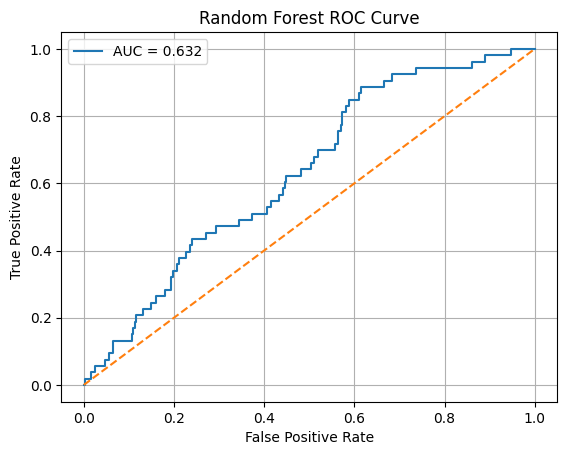

Submission shape: (486, 2)
Saved submission file: my_submission.csv


In [ ]:
# =====================================
# 1. Load train & test
# =====================================
train = pd.read_csv("train_data.csv")
test  = pd.read_csv("test_data.csv")

y = (train["Churn"] == "Yes").astype(int).values

train_feat = train.drop(columns=["Churn"])
test_ids = test["ID"].copy()
test_feat = test.drop(columns=["ID"])

# Combine for matching one-hot encoding
full = pd.concat([train_feat, test_feat], axis=0, ignore_index=True)

# =====================================
# 2. Feature engineering: TenureDays
# =====================================
full["DateOfServiceStart"] = pd.to_datetime(full["DateOfServiceStart"], format='mixed', dayfirst=False)
ref_date = full["DateOfServiceStart"].max()
full["TenureDays"] = (ref_date - full["DateOfServiceStart"]).dt.days
full = full.drop(columns=["DateOfServiceStart"])

# =====================================
# 3. Handle missing values + encoding
# =====================================
num_cols = full.select_dtypes(include=["int64", "float64"]).columns
cat_cols = full.select_dtypes(include=["object"]).columns

# Numeric → median
full[num_cols] = full[num_cols].fillna(full[num_cols].median())

# Categorical → mode
for col in cat_cols:
    full[col] = full[col].fillna(full[col].mode()[0])

# One-hot encode
full = pd.get_dummies(full, columns=cat_cols, drop_first=True)

# Split back
X_all = full.iloc[:len(train), :].values
X_test_final = full.iloc[len(train):, :].values

# =====================================
# 4. Train / validation split
# =====================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

X_train, X_valid, y_train, y_valid = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Valid shape:", X_valid.shape)

# =====================================
# 5. RANDOM FOREST — tuned for AUC
# =====================================
rf = RandomForestClassifier(
    n_estimators=700,               # MORE TREES = higher AUC
    max_depth=12,                  # prevents overfitting
    min_samples_split=20,
    min_samples_leaf=10,           # stabilizes predictions
    max_features="sqrt",
    bootstrap=True,
    class_weight="balanced",       # IMPORTANT
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# =====================================
# 6. Validation results (AUC target: ~0.75–0.80)
# =====================================
valid_probs = rf.predict_proba(X_valid)[:, 1]
valid_auc = roc_auc_score(y_valid, valid_probs)

print(f"Validation AUC: {valid_auc:.4f}")

threshold = 0.35  # better for imbalance
valid_preds = (valid_probs >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_valid, valid_preds))
print("Precision:", precision_score(y_valid, valid_preds))
print("Recall:", recall_score(y_valid, valid_preds))
print("F1:", f1_score(y_valid, valid_preds))
print("Confusion Matrix:\n", confusion_matrix(y_valid, valid_preds))

# ROC Curve
fpr, tpr, _ = roc_curve(y_valid, valid_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# =====================================
# 7. Retrain on ALL data
# =====================================
rf_full = RandomForestClassifier(
    n_estimators=700,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    bootstrap=True,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_full.fit(X_all, y)

# Test predictions
test_probs = rf_full.predict_proba(X_test_final)[:, 1]

# =====================================
# 8. Export submission CSV (486 rows)
# =====================================
submission = pd.DataFrame({
    "ID": test_ids,
    "ChurnProb": test_probs
})

print("Submission shape:", submission.shape)  # should be (486, 2)
submission.to_csv("mywokkkk_submission.csv", index=False)
print("Saved submission file: my_submission.csv")

In [ ]:
# =====================================
# Random Forest – MAX AUC Optimized
# =====================================

from sklearn.model_selection import RandomizedSearchCV

# VERY wide search space optimized for churn datasets
param_dist_rf = {
    "n_estimators": [500, 700, 900, 1200],        # deep forests
    "max_depth": [None, 10, 15, 20, 25, 30],      # allow deep splits
    "min_samples_split": [2, 5, 10, 20, 40],
    "min_samples_leaf": [1, 2, 4, 8, 12],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True],
    "class_weight": ["balanced", "balanced_subsample"]
}

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Randomized search for AUC
rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=486,                  # number of combinations to test
    scoring="roc_auc",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("BEST RF PARAMS:", rf_search.best_params_)
print("BEST CV AUC:", rf_search.best_score_)

# Evaluate best model
best_rf = rf_search.best_estimator_

valid_probs = best_rf.predict_proba(X_valid)[:, 1]
valid_auc = roc_auc_score(y_valid, valid_probs)

print("Validation AUC:", valid_auc)

threshold = 0.35
valid_preds = (valid_probs >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_valid, valid_preds))
print("Precision:", precision_score(y_valid, valid_preds))
print("Recall:", recall_score(y_valid, valid_preds))
print("F1:", f1_score(y_valid, valid_preds))
print("Confusion Matrix:\n", confusion_matrix(y_valid, valid_preds))

# =====================================
# Refit best model on ALL data
# =====================================
best_rf.fit(X_all, y)
test_probs = best_rf.predict_proba(X_test_final)[:, 1]

submission = pd.DataFrame({
    "ID": test_ids,
    "ChurnProb": test_probs
})

submission.to_csv("my_wadsubmission.csv", index=False)
print("CSV saved!")


Fitting 3 folds for each of 486 candidates, totalling 1458 fits
